# A simple 2D Flow Matching model

This notebook trains and evaluates a simple 2D FM model with CondOT (i.e., linear) scheduler.

Dataset: 2D checkerboard
Model (velocity): MLP

## Imports and init device

In [1]:
import time
import torch

from torch import nn, Tensor

# flow_matching
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

# visualization
import matplotlib.pyplot as plt

from matplotlib import cm


# To avoide meshgrid warning
import warnings

from sklearn.datasets import make_moons
import numpy as np
from scipy.stats import vonmises as scipy_vonmises
from scipy.stats import lognorm as scipy_lognorm

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [2]:
if torch.cuda.is_available():
    device = 'cuda:0'
    print('Using gpu')
else:
    device = 'cpu'
    print('Using cpu.')

Using gpu


In [3]:
torch.manual_seed(0)

## Dataset

In [4]:
def inf_train_gen(batch_size: int = 200, device: str = "cpu"):
    x1 = torch.rand(batch_size, device=device) * 4 - 2
    x2_ = torch.rand(batch_size, device=device) - torch.randint(high=2, size=(batch_size, ), device=device) * 2
    x2 = x2_ + (torch.floor(x1) % 2)

    data = 1.0 * torch.cat([x1[:, None], x2[:, None]], dim=1) / 0.45
    
    return data.float()

In [5]:
def two_moons_data(batch_size: int = 200, device: str = "cpu"):
    x, _ = make_moons(n_samples=batch_size, noise=0.1, random_state=42)
    data = torch.tensor(x, device=device).float()
    return data

In [6]:
def two_moons_data_with_cond(batch_size: int = 200, device: str = "cpu"):
    x, y = make_moons(n_samples=batch_size, noise=0.1, random_state=42)
    data = torch.tensor(x, device=device).float()
    cond = torch.tensor(y, device=device).float()
    
    total_data = torch.cat([data, cond[:, None]], dim=1)
    return total_data

In [7]:
def multi_blob_data_with_cond(batch_size: int = 200, n_classes: int = 4, noise: float = 0.4, device: str = "cpu"):
    """
    Generates a toy dataset with multiple blobs, where each blob is a class.
    """
    # Define the centers for the blobs
    angles = torch.linspace(0, 2 * torch.pi, n_classes + 1, device=device)[:-1]
    radius = 2.5
    centers = torch.stack([radius * torch.cos(angles), radius * torch.sin(angles)], dim=1)
    
    # Assign each point in the batch to a random class
    y = torch.randint(0, n_classes, (batch_size,), device=device)
    
    # Create the data points by selecting the center and adding noise
    x = centers[y] + torch.randn(batch_size, 2, device=device) * noise
    
    data = x.float()
    cond = y.float()
    
    total_data = torch.cat([data, cond[:, None]], dim=1)
    return total_data

In [8]:
def semicircle_data():
    """
    Loads the semicircle dataset.
    """

    data = torch.load("../NLOT/data/conditional_semicircles.pt")
    data = data.to(device)
    return data

## Model

In [9]:
# Activation class
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class
class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 1):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_dim+cond_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
            )
    

    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t, cond], dim=1)
        output = self.main(h)
        
        return output.reshape(*sz)

In [10]:
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class with FiLM conditioning
class FiLMMLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 1):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim
        
        # Main network layers
        self.input_layer = nn.Linear(input_dim + time_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(3)
        ])
        self.output_layer = nn.Linear(hidden_dim, input_dim)
        
        self.activation = Swish()
        
        # FiLM generator network
        # It will generate gammas and betas for the 4 layers (input + 3 hidden)
        num_film_layers = len(self.hidden_layers) + 1 
        self.film_generator = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            self.activation,
            nn.Linear(hidden_dim, num_film_layers * hidden_dim * 2) # *2 for gamma and beta
        )
        
    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        # Expand time to match batch size
        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        
        # Generate FiLM parameters from condition
        film_params = self.film_generator(cond)
        
        # Split FiLM params into gammas and betas for each layer
        num_film_layers = len(self.hidden_layers) + 1
        gammas = film_params[:, :num_film_layers * self.hidden_dim].reshape(-1, num_film_layers, self.hidden_dim)
        betas = film_params[:, num_film_layers * self.hidden_dim:].reshape(-1, num_film_layers, self.hidden_dim)

        # Main forward pass
        h = torch.cat([x, t], dim=1)
        
        # Input layer
        h = self.input_layer(h)
        h = gammas[:, 0, :] * h + betas[:, 0, :] # Apply FiLM
        h = self.activation(h)
        
        # Hidden layers
        for i, layer in enumerate(self.hidden_layers):
            h = layer(h)
            h = gammas[:, i + 1, :] * h + betas[:, i + 1, :] # Apply FiLM
            h = self.activation(h)
            
        # Output layer
        output = self.output_layer(h)
        
        return output.reshape(*sz)

## Train Velocity Flow Matching model

In [136]:
# training arguments
lr = 0.001
batch_size = 4096
iterations = 20001
print_every = 2000 
hidden_dim = 512

# velocity field model for time 0 to 0.5 init
vf_0 = MLP(input_dim=2, time_dim=1, cond_dim=1, hidden_dim=hidden_dim).to(device) 

# instantiate an affine path object
path = AffineProbPath(scheduler=CondOTScheduler())

# init optimizer
optim = torch.optim.Adam(vf_0.parameters(), lr=lr) 

# train
start_time = time.time()
print('Training velocity field model for time 0 to 0.5')
for i in range(iterations):
    optim.zero_grad() 

    # sample data (user's responsibility): in this case, (X_0,X_1) ~ pi(X_0,X_1) = N(X_0|0,I)q(X_1)
    data = semicircle_data()
    x_1 = data[1, :, :2] # sample data
    conds = data[1, :,2]
    #x_0 = torch.randn_like(x_1).to(device)
    x_0 = data[0,:,:2]

    # sample time (user's responsibility)
    t = torch.rand(x_1.shape[0]).to(device) 

    # sample probability path
    path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)

    # flow matching l2 loss
    loss = torch.pow(vf_0(path_sample.x_t,path_sample.t, conds) - path_sample.dx_t, 2).mean() 

    # optimizer step
    loss.backward() # backward
    optim.step() # update
    
    # log loss
    if (i+1) % print_every == 0:
        elapsed = time.time() - start_time
        print('| iter {:6d} | {:5.2f} ms/step | loss {:8.3f} ' 
              .format(i+1, elapsed*1000/print_every, loss.item())) 
        start_time = time.time()

# velocity field model for time 0.5 to 1.0 init
vf_1 = MLP(input_dim=2, time_dim=1, cond_dim=1, hidden_dim=hidden_dim).to(device) 

# instantiate an affine path object
path = AffineProbPath(scheduler=CondOTScheduler())

# init optimizer
optim = torch.optim.Adam(vf_1.parameters(), lr=lr) 

# train
start_time = time.time()
print('Training velocity field model for time 0.5 to 1.0')
for i in range(iterations):
    optim.zero_grad() 

    # sample data (user's responsibility): in this case, (X_0,X_1) ~ pi(X_0,X_1) = N(X_0|0,I)q(X_1)
    data = semicircle_data()
    x_1 = data[2, :, :2] # sample data
    conds = data[2, :,2]
    #x_0 = torch.randn_like(x_1).to(device)
    x_0 = data[1,:,:2]

    # sample time (user's responsibility)
    t = torch.rand(x_1.shape[0]).to(device) 

    # sample probability path
    path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)

    # flow matching l2 loss
    loss = torch.pow(vf_1(path_sample.x_t,path_sample.t, conds) - path_sample.dx_t, 2).mean() 

    # optimizer step
    loss.backward() # backward
    optim.step() # update
    
    # log loss
    if (i+1) % print_every == 0:
        elapsed = time.time() - start_time
        print('| iter {:6d} | {:5.2f} ms/step | loss {:8.3f} ' 
              .format(i+1, elapsed*1000/print_every, loss.item())) 
        start_time = time.time()

Training velocity field model for time 0 to 0.5


| iter   2000 |  2.41 ms/step | loss    0.040 
| iter   4000 |  2.37 ms/step | loss    0.039 
| iter   6000 |  2.36 ms/step | loss    0.034 
| iter   8000 |  2.34 ms/step | loss    0.028 
| iter  10000 |  2.36 ms/step | loss    0.020 
| iter  12000 |  2.36 ms/step | loss    0.025 
| iter  14000 |  2.34 ms/step | loss    0.017 
| iter  16000 |  2.30 ms/step | loss    0.014 
| iter  18000 |  2.29 ms/step | loss    0.014 
| iter  20000 |  2.46 ms/step | loss    0.013 
Training velocity field model for time 0.5 to 1.0
| iter   2000 |  2.34 ms/step | loss    0.050 
| iter   4000 |  2.37 ms/step | loss    0.050 
| iter   6000 |  2.38 ms/step | loss    0.032 
| iter   8000 |  2.37 ms/step | loss    0.033 
| iter  10000 |  2.41 ms/step | loss    0.030 
| iter  12000 |  2.43 ms/step | loss    0.030 
| iter  14000 |  2.42 ms/step | loss    0.024 
| iter  16000 |  2.44 ms/step | loss    0.022 
| iter  18000 |  2.44 ms/step | loss    0.018 
| iter  20000 |  2.40 ms/step | loss    0.018 


#### Sample from trained model

In [ ]:
class WrappedModel(ModelWrapper):
    def forward(self, x: torch.Tensor, t: torch.Tensor, cond: torch.Tensor, **extras):
        return self.model(x, t, cond)

wrapped_vf_0 = WrappedModel(vf_0)
wrapped_vf_1 = WrappedModel(vf_1)

In [142]:
# step size for ode solver
step_size = 0.05

norm = cm.colors.Normalize(vmax=50, vmin=0)

batch_size = 50000  # batch size
eps_time = 1e-2
T = torch.linspace(0,1,3)  # sample times
T = T.to(device=device)

#x_init = torch.randn((batch_size, 2), dtype=torch.float32, device=device)
x_init = data[0,:,:2]
#cond = torch.randint(0, 4, (batch_size, 1), device=device).float()
cond = data[0,:,2]

x_1_init = data[1,:,:2]  # initial condition for the second time step

solver_0 = ODESolver(velocity_model=wrapped_vf_0)  # create an ODESolver class
sol_0 = solver_0.sample(time_grid=T, x_init=x_init, cond=cond, method='midpoint', step_size=step_size, return_intermediates=True)  # sample from the model

solver_1 = ODESolver(velocity_model=wrapped_vf_1) 
sol_1 = solver_1.sample(time_grid=T, x_init=x_1_init, cond=cond, method='midpoint', step_size=step_size, return_intermediates=True)  # sample from the model

### Visualize the path

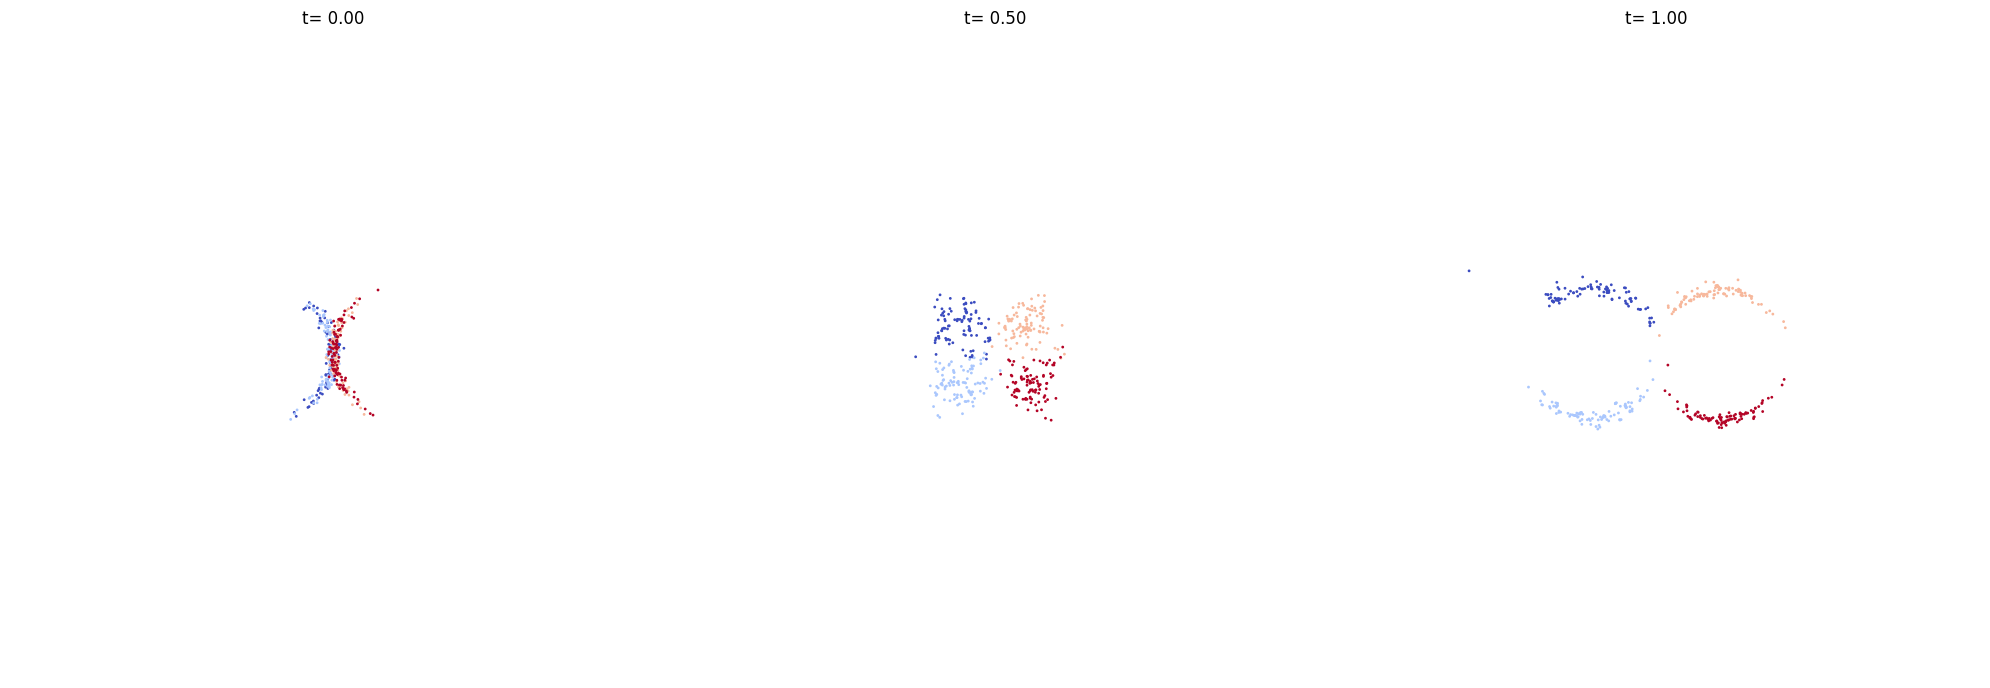

In [143]:
sol_0 = sol_0.cpu().numpy()
T = T.cpu()
cond = cond.cpu().numpy()

fig, axs = plt.subplots(1, 3,figsize=(20,20))

for i in range(3):
    axs[i].scatter(sol_0[i,:,0], sol_0[i,:,1], c=cond, cmap=cm.coolwarm, s=1)
    
    axs[i].set_aspect('equal')
    axs[i].axis('off')
    axs[i].set_xlim(-5, 5)
    axs[i].set_ylim(-5, 5)
    axs[i].set_title('t= %.2f' % (T[i]))
    
plt.tight_layout()
plt.show()

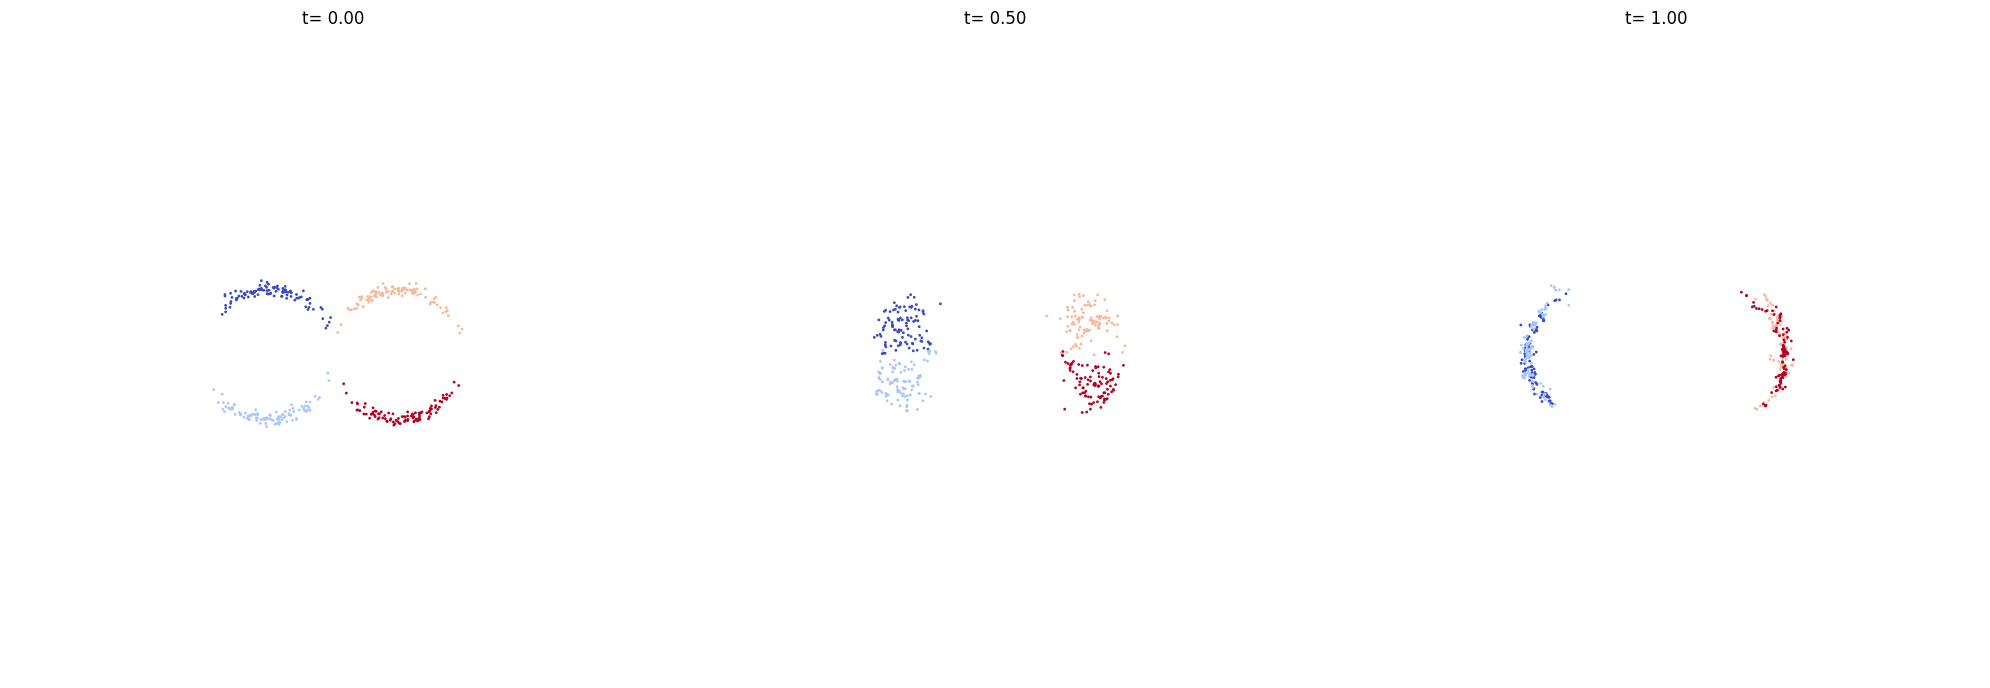

In [144]:
sol_1 = sol_1.cpu().numpy()
T = T.cpu()

fig, axs = plt.subplots(1, 3,figsize=(20,20))

for i in range(3):
    axs[i].scatter(sol_1[i,:,0], sol_1[i,:,1], c=cond, cmap=cm.coolwarm, s=1)
    
    axs[i].set_aspect('equal')
    axs[i].axis('off')
    axs[i].set_xlim(-5, 5)
    axs[i].set_ylim(-5, 5)
    axs[i].set_title('t= %.2f' % (T[i]))
    
plt.tight_layout()
plt.show()

In [146]:
sol_0_midpoint_w_cond = np.concatenate([sol_0[1,:,:], cond[:, None]], axis=1)
sol_1_midpoint_w_cond = np.concatenate([sol_1[1,:,:], cond[:, None]], axis=1)

In [147]:
def log_likelihood_conditional_semicircle(
        data: torch.Tensor, # Shape (N, 3): [x, y, condition]
        time: float,
        radius: float = 1.0,
        angular_concentration: float = 5.0,
        radial_std_dev: float = 0.05 # Std dev for log(radius), 's' parameter for lognorm
    ) -> float:
    """
    Calculates the total log-likelihood of the given data under the semicircle model
    for a specific time and model parameters.

    Args:
        data (torch.Tensor): Input data of shape (N, 3), where columns are [x, y, condition].
                             Conditions should be integers 0, 1, 2, 3.
        time (float): Continuous time at which the data is assumed to be generated.
        radius (float): Radius of the semicircles.
        angular_concentration (float): Concentration parameter for the von Mises distribution.
        radial_std_dev (float): Standard deviation for the log of the radial distribution.

    Returns:
        float: The total log-likelihood of the dataset.
    """
    if data.ndim != 2 or data.shape[1] != 3:
        raise ValueError("Input data must have shape (N, 3)")

    data_np = data.cpu().numpy()
    x_coords = data_np[:, 0]
    y_coords = data_np[:, 1]
    conditions = data_np[:, 2].astype(int)

    total_log_likelihood = 0.0
    
    log_normal_mu_param = np.log(radius) # mu parameter for the underlying normal of lognorm

    for c_val in range(4):
        mask = (conditions == c_val)
        if not np.any(mask):
            continue

        current_x = x_coords[mask]
        current_y = y_coords[mask]

        # Determine target angle and center for the condition and time
        if c_val == 0:
            target_angle = time * np.pi
            center_x = -1.0
        elif c_val == 1:
            target_angle = -time * np.pi
            center_x = -1.0
        elif c_val == 2:
            target_angle = np.pi - time * np.pi
            center_x = 1.0
        else:  # c_val == 3
            target_angle = -np.pi + time * np.pi
            center_x = 1.0
        
        x_local = current_x - center_x
        y_local = current_y 

        epsilon = 1e-9 # To avoid log(0) or issues with r_polar=0
        r_polar = np.sqrt(x_local**2 + y_local**2)
        theta_polar = np.arctan2(y_local, x_local)

        log_pdf_angles = scipy_vonmises.logpdf(theta_polar, loc=target_angle, kappa=angular_concentration)
        valid_radii_mask = r_polar > epsilon
        log_pdf_radii = np.full_like(r_polar, -np.inf)

        if np.any(valid_radii_mask):
            log_pdf_radii[valid_radii_mask] = scipy_lognorm.logpdf(
                r_polar[valid_radii_mask],
                s=radial_std_dev,                # Shape parameter (sigma of underlying log)
                loc=0,                           # Shift parameter
                scale=np.exp(log_normal_mu_param) # Scale parameter (exp(mu of underlying log))
            )

        # Jacobian for polar to Cartesian transformation: pdf_cartesian = pdf_polar / r
        # So, log_pdf_cartesian = log_pdf_polar - log(r)
        log_jacobian_term = np.full_like(r_polar, -np.inf)
        if np.any(valid_radii_mask):
            log_jacobian_term[valid_radii_mask] = -np.log(r_polar[valid_radii_mask])

        # Sum log likelihoods for points in this condition (only for valid radii)
        current_log_likelihood = np.sum(
            log_pdf_angles[valid_radii_mask] + \
            log_pdf_radii[valid_radii_mask] + \
            log_jacobian_term[valid_radii_mask]
        )
        
        total_log_likelihood += current_log_likelihood
        
    return float(total_log_likelihood)

In [ ]:
circle_centers = {0: np.array([-1.0, 0.0]), 1: np.array([-1.0, 0.0]), 2: np.array([1.0, 0.0]), 3: np.array([1.0, 0.0])}
circle_radius = 1.0
per_condition_circle_dist = []

for cond_idx, true_cond_vec in enumerate(unique_true_conditions):
    true_cond_mask = np.all(true_conditions_all == true_cond_vec, axis=1)
    pred_cond_mask = np.all(predicted_conditions_all == true_cond_vec, axis=1)

    pred_samples_for_cond = predicted_spatial_overall[pred_cond_mask]

    if pred_samples_for_cond.shape[0] > 0:
        center = circle_centers[cond_idx]
        distances = np.abs(np.linalg.norm(pred_samples_for_cond - center, axis=1) - circle_radius)
        avg_distance = np.mean(distances)
        per_condition_circle_dist.append(avg_distance)
        metrics_log[f"time_{eval_time:.4f}_cond_{cond_idx}_circle_dist"] = float(avg_distance)

if per_condition_circle_dist:
    avg_circle_dist = np.mean(np.array(per_condition_circle_dist))
    metrics_log[f"time_{eval_time:.4f}_avg_circle_dist"] = float(avg_circle_dist)
    all_circle_distances.extend(per_condition_circle_dist)
    if verbose:
        print(f"Avg Circle Distance Across Conditions: {avg_circle_dist:.4e}")

In [161]:
circle_centers = {0: np.array([-1.0, 0.0]), 1: np.array([-1.0, 0.0]), 2: np.array([1.0, 0.0]), 3: np.array([1.0, 0.0])}
circle_radius = 1.0
per_condition_circle_dist = []

for cond_idx, cond_vec in enumerate([0,1,2,3]):
    all_midpoint_samples = np.vstack((sol_0_midpoint_w_cond, sol_1_midpoint_w_cond))
    #select samples from all_midpoint_samples that match the condition
    cond_mask = all_midpoint_samples[:, -1] == cond_vec
    cond_samples = all_midpoint_samples[cond_mask, :-1]
    center = circle_centers[cond_idx]
    distances = np.abs(np.linalg.norm(cond_samples - center, axis=1) - circle_radius)
    avg_distance = np.mean(distances)
    per_condition_circle_dist.append(avg_distance)

avg_circle_dist = np.mean(np.array(per_condition_circle_dist))
print(f"Avg Circle Distance Across Conditions: {avg_circle_dist}")

Avg Circle Distance Across Conditions: 0.3221959247820433


In [163]:
nll_0 = -log_likelihood_conditional_semicircle(torch.tensor(sol_0_midpoint_w_cond), time=0.25)/400
nll_1 = -log_likelihood_conditional_semicircle(torch.tensor(sol_1_midpoint_w_cond), time=0.75)/400

avg_nll = (nll_0 + nll_1) / 2
print(f"Average Negative Log-Likelihood: {avg_nll}")

Average Negative Log-Likelihood: 98.32533174374133


# CFM Semicircles results

In [167]:
cfm_nlls = []
cfm_cds = []

for i in range(5):
    print('ITERATION', i)
    lr = 0.001
    batch_size = 4096
    iterations = 20001
    print_every = 2000 
    hidden_dim = 512

    # velocity field model for time 0 to 0.5 init
    vf_0 = MLP(input_dim=2, time_dim=1, cond_dim=1, hidden_dim=hidden_dim).to(device) 

    # instantiate an affine path object
    path = AffineProbPath(scheduler=CondOTScheduler())

    # init optimizer
    optim = torch.optim.Adam(vf_0.parameters(), lr=lr) 

    # train
    start_time = time.time()
    print('Training velocity field model for time 0 to 0.5')
    for i in range(iterations):
        optim.zero_grad() 

        # sample data (user's responsibility): in this case, (X_0,X_1) ~ pi(X_0,X_1) = N(X_0|0,I)q(X_1)
        data = semicircle_data()
        x_1 = data[1, :, :2] # sample data
        conds = data[1, :,2]
        #x_0 = torch.randn_like(x_1).to(device)
        x_0 = data[0,:,:2]

        # sample time (user's responsibility)
        t = torch.rand(x_1.shape[0]).to(device) 

        # sample probability path
        path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)

        # flow matching l2 loss
        loss = torch.pow(vf_0(path_sample.x_t,path_sample.t, conds) - path_sample.dx_t, 2).mean() 

        # optimizer step
        loss.backward() # backward
        optim.step() # update
        
        # log loss
        if (i+1) % print_every == 0:
            elapsed = time.time() - start_time
            print('| iter {:6d} | {:5.2f} ms/step | loss {:8.3f} ' 
                .format(i+1, elapsed*1000/print_every, loss.item())) 
            start_time = time.time()

    # velocity field model for time 0.5 to 1.0 init
    vf_1 = MLP(input_dim=2, time_dim=1, cond_dim=1, hidden_dim=hidden_dim).to(device) 

    # instantiate an affine path object
    path = AffineProbPath(scheduler=CondOTScheduler())

    # init optimizer
    optim = torch.optim.Adam(vf_1.parameters(), lr=lr) 

    # train
    start_time = time.time()
    print('Training velocity field model for time 0.5 to 1.0')
    for i in range(iterations):
        optim.zero_grad() 

        # sample data (user's responsibility): in this case, (X_0,X_1) ~ pi(X_0,X_1) = N(X_0|0,I)q(X_1)
        data = semicircle_data()
        x_1 = data[2, :, :2] # sample data
        conds = data[2, :,2]
        #x_0 = torch.randn_like(x_1).to(device)
        x_0 = data[1,:,:2]

        # sample time (user's responsibility)
        t = torch.rand(x_1.shape[0]).to(device) 

        # sample probability path
        path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)

        # flow matching l2 loss
        loss = torch.pow(vf_1(path_sample.x_t,path_sample.t, conds) - path_sample.dx_t, 2).mean() 

        # optimizer step
        loss.backward() # backward
        optim.step() # update
        
        # log loss
        if (i+1) % print_every == 0:
            elapsed = time.time() - start_time
            print('| iter {:6d} | {:5.2f} ms/step | loss {:8.3f} ' 
                .format(i+1, elapsed*1000/print_every, loss.item())) 
            start_time = time.time()

    class WrappedModel(ModelWrapper):
        def forward(self, x: torch.Tensor, t: torch.Tensor, cond: torch.Tensor, **extras):
            return self.model(x, t, cond)

    wrapped_vf_0 = WrappedModel(vf_0)
    wrapped_vf_1 = WrappedModel(vf_1)

    # step size for ode solver
    step_size = 0.05

    norm = cm.colors.Normalize(vmax=50, vmin=0)

    batch_size = 50000  # batch size
    eps_time = 1e-2
    T = torch.linspace(0,1,3)  # sample times
    T = T.to(device=device)

    #x_init = torch.randn((batch_size, 2), dtype=torch.float32, device=device)
    x_init = data[0,:,:2]
    #cond = torch.randint(0, 4, (batch_size, 1), device=device).float()
    cond = data[0,:,2]

    x_1_init = data[1,:,:2]  # initial condition for the second time step

    solver_0 = ODESolver(velocity_model=wrapped_vf_0)  # create an ODESolver class
    sol_0 = solver_0.sample(time_grid=T, x_init=x_init, cond=cond, method='midpoint', step_size=step_size, return_intermediates=True)  # sample from the model

    solver_1 = ODESolver(velocity_model=wrapped_vf_1) 
    sol_1 = solver_1.sample(time_grid=T, x_init=x_1_init, cond=cond, method='midpoint', step_size=step_size, return_intermediates=True)  # sample from the model

    sol_0 = sol_0.cpu().numpy()
    sol_1 = sol_1.cpu().numpy()
    cond = cond.cpu().numpy()
    T = T.cpu()

    sol_0_midpoint_w_cond = np.concatenate([sol_0[1,:,:], cond[:, None]], axis=1)
    sol_1_midpoint_w_cond = np.concatenate([sol_1[1,:,:], cond[:, None]], axis=1)



    nll_0 = -log_likelihood_conditional_semicircle(torch.tensor(sol_0_midpoint_w_cond), time=0.25)/400
    nll_1 = -log_likelihood_conditional_semicircle(torch.tensor(sol_1_midpoint_w_cond), time=0.75)/400

    avg_nll = (nll_0 + nll_1) / 2
    print(f"Average Negative Log-Likelihood: {avg_nll}")
    cfm_nlls.append(avg_nll)


    circle_centers = {0: np.array([-1.0, 0.0]), 1: np.array([-1.0, 0.0]), 2: np.array([1.0, 0.0]), 3: np.array([1.0, 0.0])}
    circle_radius = 1.0
    per_condition_circle_dist = []

    for cond_idx, cond_vec in enumerate([0,1,2,3]):
        all_midpoint_samples = np.vstack((sol_0_midpoint_w_cond, sol_1_midpoint_w_cond))
        #select samples from all_midpoint_samples that match the condition
        cond_mask = all_midpoint_samples[:, -1] == cond_vec
        cond_samples = all_midpoint_samples[cond_mask, :-1]
        center = circle_centers[cond_idx]
        distances = np.abs(np.linalg.norm(cond_samples - center, axis=1) - circle_radius)
        avg_distance = np.mean(distances)
        per_condition_circle_dist.append(avg_distance)

    avg_circle_dist = np.mean(np.array(per_condition_circle_dist))
    
    print(f"Avg Circle Distance Across Conditions: {avg_circle_dist}")
    cfm_cds.append(avg_circle_dist)
    

    

ITERATION 0
Training velocity field model for time 0 to 0.5


| iter   2000 |  2.29 ms/step | loss    0.042 
| iter   4000 |  2.19 ms/step | loss    0.039 
| iter   6000 |  2.21 ms/step | loss    0.031 
| iter   8000 |  2.16 ms/step | loss    0.032 
| iter  10000 |  2.33 ms/step | loss    0.031 
| iter  12000 |  2.34 ms/step | loss    0.021 
| iter  14000 |  2.34 ms/step | loss    0.021 
| iter  16000 |  2.32 ms/step | loss    0.017 
| iter  18000 |  2.20 ms/step | loss    0.015 
| iter  20000 |  2.16 ms/step | loss    0.012 
Training velocity field model for time 0.5 to 1.0
| iter   2000 |  2.39 ms/step | loss    0.046 
| iter   4000 |  2.45 ms/step | loss    0.040 
| iter   6000 |  2.34 ms/step | loss    0.035 
| iter   8000 |  2.29 ms/step | loss    0.034 
| iter  10000 |  2.33 ms/step | loss    0.031 
| iter  12000 |  2.38 ms/step | loss    0.030 
| iter  14000 |  2.37 ms/step | loss    0.026 
| iter  16000 |  2.30 ms/step | loss    0.019 
| iter  18000 |  2.40 ms/step | loss    0.020 
| iter  20000 |  2.44 ms/step | loss    0.013 
Average Ne

In [168]:
cfm_cds

[0.33953084520205123,
 0.3214014870939345,
 0.33182925488823745,
 0.32778488611937573,
 0.3142215719881015]

In [169]:
cfm_nlls

[97.5503541242816,
 99.47670691209676,
 99.9703188602732,
 95.55106689594058,
 84.24794472582178]

In [22]:
def print_results(results, name):
    mean = np.mean(results)
    std = np.std(results)
    ci = 1.96 * std / np.sqrt(len(results))
    print(f"{name}: {mean:.3f} ± {ci:.3f}")

In [173]:
print_results(cfm_nlls, "CFM NLL")
print_results(cfm_cds, "CFM Circle Distances")

CFM NLL: 95.359 ± 5.058
CFM Circle Distances: 0.327 ± 0.008


# CFM Reward Weighting

In [12]:
def rl_data_gen():
    """
    Loads the rl reward weighting dataset.
    """

    data = torch.load("../NLOT/data/reward_weighting_data_0_10.pt")
    data = data.to(device)
    return data

In [13]:
rl_data = rl_data_gen()
rl_data = rl_data[:,:1000]

In [14]:
rl_data.shape

torch.Size([11, 1000, 9])

In [24]:
class WrappedModel(ModelWrapper):
        def forward(self, x: torch.Tensor, t: torch.Tensor, cond: torch.Tensor, **extras):
            return self.model(x, t, cond)

In [ ]:
for model_i in range(5):
    print(f"Iteration {i+1} of 5")
    # training arguments
    lr = 0.001
    batch_size = 1000
    iterations = 100001
    print_every = 2000 
    hidden_dim = 128
    patience = 250  # Early stopping patience
    min_delta = 1e-6  # Minimum improvement threshold
    validation_split = 0.1  # Use 10% of data for validation

    # Split data for validation
    num_samples = rl_data.shape[1]
    val_size = int(num_samples * validation_split)
    val_indices = torch.randperm(num_samples)[:val_size]
    train_indices = torch.randperm(num_samples)[val_size:]

    vf_0 = MLP(input_dim=2, time_dim=1, cond_dim=7, hidden_dim=hidden_dim).to(device) 
    path = AffineProbPath(scheduler=CondOTScheduler())
    optim = torch.optim.Adam(vf_0.parameters(), lr=lr) 

    # Early stopping variables for first model
    best_val_loss_0 = float('inf')
    patience_counter_0 = 0
    best_model_state_0 = None

    start_time = time.time()
    print('Training velocity field model for time 0 to 0.5')
    print("-" * 60)
    for i in range(iterations):
        # Training phase
        vf_0.train()
        optim.zero_grad() 

        # Use training indices only
        x_1 = rl_data[5, train_indices, :2] 
        x_0 = rl_data[0, train_indices, :2]
        conds = rl_data[0, train_indices, 2:]
        t = torch.rand(x_1.shape[0]).to(device) 
        path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)
        train_loss = torch.pow(vf_0(path_sample.x_t, path_sample.t, conds) - path_sample.dx_t, 2).mean() 
        train_loss.backward() 
        optim.step()
        
        # Validation phase
        if i % 100 == 0:  # Validate every 100 iterations
            vf_0.eval()
            with torch.no_grad():
                x_1_val = rl_data[5, val_indices, :2] 
                x_0_val = rl_data[0, val_indices, :2]
                conds_val = rl_data[0, val_indices, 2:]
                t_val = torch.rand(x_1_val.shape[0]).to(device) 
                path_sample_val = path.sample(t=t_val, x_0=x_0_val, x_1=x_1_val)
                val_loss = torch.pow(vf_0(path_sample_val.x_t, path_sample_val.t, conds_val) - path_sample_val.dx_t, 2).mean()
                
                # Early stopping check
                if val_loss < best_val_loss_0 - min_delta:
                    best_val_loss_0 = val_loss
                    patience_counter_0 = 0
                    best_model_state_0 = vf_0.state_dict().copy()
                else:
                    patience_counter_0 += 1

        # Print progress
        if (i+1) % print_every == 0:
            elapsed = time.time() - start_time
            print('| iter {:6d} | {:5.2f} ms/step | train loss {:8.3f} | val loss {:8.3f} | patience {:3d}/{:3d}' 
                .format(i+1, elapsed*1000/print_every, train_loss.item(), val_loss.item(), patience_counter_0, patience)) 
            start_time = time.time()
        
        # Early stopping
        if patience_counter_0 >= patience:
            print(f"Early stopping triggered at iteration {i+1}")
            print(f"Best validation loss: {best_val_loss_0:.6f}")
            if best_model_state_0 is not None:
                vf_0.load_state_dict(best_model_state_0)
                print("Restored best model weights")
            break

    print(f"Training completed for vf_0 after {i+1} iterations")

    # Second model training with early stopping
    vf_1 = MLP(input_dim=2, time_dim=1, cond_dim=7, hidden_dim=hidden_dim).to(device) 
    path = AffineProbPath(scheduler=CondOTScheduler())
    optim = torch.optim.Adam(vf_1.parameters(), lr=lr) 

    # Early stopping variables for second model
    best_val_loss_1 = float('inf')
    patience_counter_1 = 0
    best_model_state_1 = None

    start_time = time.time()
    print('\nTraining velocity field model for time 0.5 to 1')
    print("-" * 60)

    for i in range(iterations):
        # Training phase
        vf_1.train()
        optim.zero_grad() 

        # Use training indices only
        x_1 = rl_data[10, train_indices, :2] 
        x_0 = rl_data[5, train_indices, :2]
        conds = rl_data[5, train_indices, 2:]
        t = torch.rand(x_1.shape[0]).to(device) 
        path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)
        train_loss = torch.pow(vf_1(path_sample.x_t, path_sample.t, conds) - path_sample.dx_t, 2).mean() 
        train_loss.backward() 
        optim.step()
        
        # Validation phase
        if i % 10 == 0:  # Validate every 100 iterations
            vf_1.eval()
            with torch.no_grad():
                x_1_val = rl_data[10, val_indices, :2] 
                x_0_val = rl_data[5, val_indices, :2]
                conds_val = rl_data[5, val_indices, 2:]
                t_val = torch.rand(x_1_val.shape[0]).to(device) 
                path_sample_val = path.sample(t=t_val, x_0=x_0_val, x_1=x_1_val)
                val_loss = torch.pow(vf_1(path_sample_val.x_t, path_sample_val.t, conds_val) - path_sample_val.dx_t, 2).mean()
                
                # Early stopping check
                if val_loss < best_val_loss_1 - min_delta:
                    best_val_loss_1 = val_loss
                    patience_counter_1 = 0
                    best_model_state_1 = vf_1.state_dict().copy()
                else:
                    patience_counter_1 += 1
        
        # Print progress
        if (i+1) % print_every == 0:
            elapsed = time.time() - start_time
            print('| iter {:6d} | {:5.2f} ms/step | train loss {:8.3f} | val loss {:8.3f} | patience {:3d}/{:3d}' 
                .format(i+1, elapsed*1000/print_every, train_loss.item(), val_loss.item(), patience_counter_1, patience)) 
            start_time = time.time()
        
        # Early stopping
        if patience_counter_1 >= patience:
            print(f"Early stopping triggered at iteration {i+1}")
            print(f"Best validation loss: {best_val_loss_1:.6f}")
            if best_model_state_1 is not None:
                vf_1.load_state_dict(best_model_state_1)
                print("Restored best model weights")
            break

    print(f"Training completed for vf_1 after {i+1} iterations")

    wrapped_vf_0 = WrappedModel(vf_0)
    wrapped_vf_1 = WrappedModel(vf_1)

    #save wrapped models

    torch.save(wrapped_vf_0.state_dict(), f'cfm_model_0_{model_i}.pt')
    torch.save(wrapped_vf_1.state_dict(), f'cfm_model_1_{model_i}.pt')

Iteration 1 of 5
Training velocity field model for time 0 to 0.5
------------------------------------------------------------
| iter   2000 |  1.24 ms/step | train loss    0.395 | val loss    0.392 | patience   7/250
| iter   4000 |  1.24 ms/step | train loss    0.394 | val loss    0.368 | patience   1/250
| iter   6000 |  1.24 ms/step | train loss    0.338 | val loss    0.364 | patience  13/250
| iter   8000 |  1.24 ms/step | train loss    0.255 | val loss    0.321 | patience   8/250
| iter  10000 |  1.24 ms/step | train loss    0.176 | val loss    0.196 | patience   0/250
| iter  12000 |  1.24 ms/step | train loss    0.141 | val loss    0.162 | patience   8/250
| iter  14000 |  1.24 ms/step | train loss    0.099 | val loss    0.164 | patience   8/250
| iter  16000 |  1.24 ms/step | train loss    0.084 | val loss    0.128 | patience   3/250
| iter  18000 |  1.23 ms/step | train loss    0.072 | val loss    0.101 | patience  14/250
| iter  20000 |  1.24 ms/step | train loss    0.059 | v

In [27]:
step_size = 0.05
T = torch.linspace(0,1,6)
T = T.to(device=device)
x_init = rl_data[0,:,:2]
cond = rl_data[0,:,2:]
solver_0 = ODESolver(velocity_model=wrapped_vf_0) 
sol_0 = solver_0.sample(time_grid=T, x_init=x_init, cond=cond, method='midpoint', step_size=step_size, return_intermediates=True) 

solver_1 = ODESolver(velocity_model=wrapped_vf_1)
x_1_init = rl_data[5,:,:2]  
sol_1 = solver_1.sample(time_grid=T, x_init=x_1_init, cond=cond, method='midpoint', step_size=step_size, return_intermediates=True)

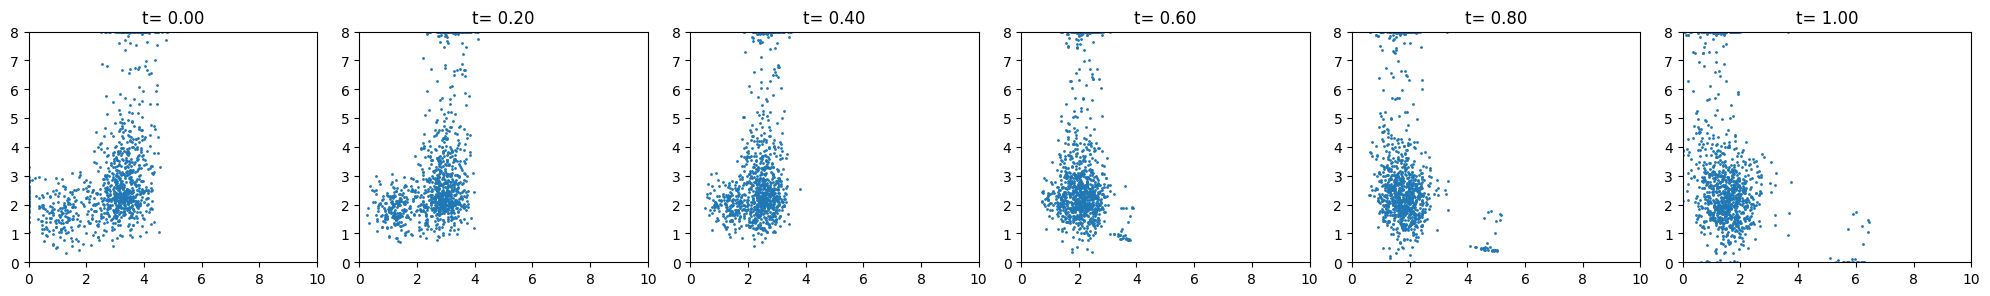

In [28]:
sol_0 = sol_0.cpu().numpy()
T = T.cpu()
cond = cond.cpu().numpy()
fig, axs = plt.subplots(1, 6,figsize=(20,20))

for i in range(6):
    #clip the values to [0,10] and [0,8]
    sol_0[i,:,0] = np.clip(sol_0[i,:,0], 0, 10)
    sol_0[i,:,1] = np.clip(sol_0[i,:,1], 0, 8)
    axs[i].scatter(sol_0[i,:,0], sol_0[i,:,1], s=1)
    axs[i].set_aspect('equal')
    axs[i].set_xlim(0, 10)
    axs[i].set_ylim(0, 8)
    axs[i].set_title('t= %.2f' % (T[i]))
    
plt.tight_layout()
plt.show()

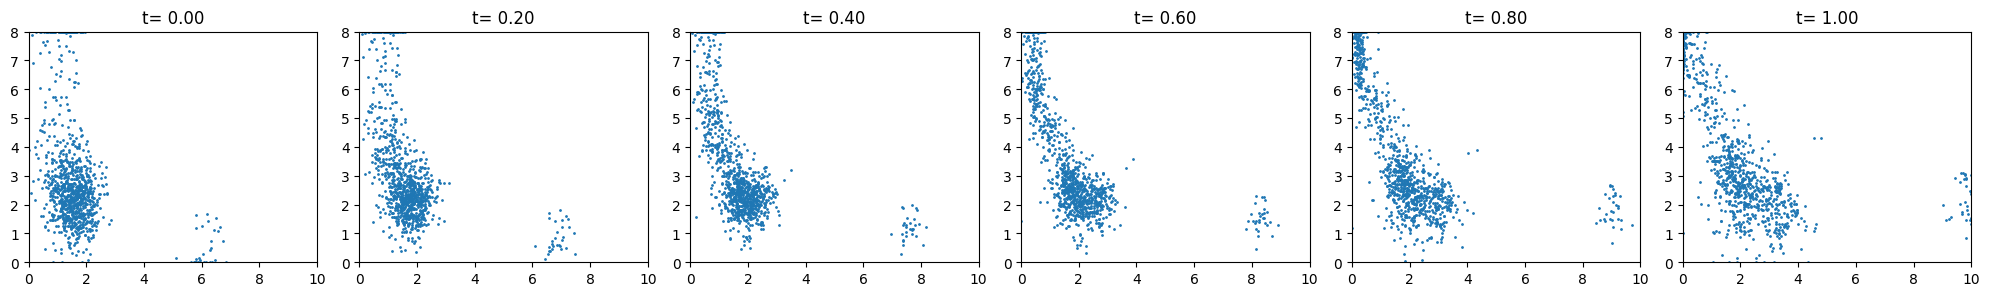

In [29]:
sol_1 = sol_1.cpu().numpy()
fig, axs = plt.subplots(1, 6,figsize=(20,20))

for i in range(6):
    #clip the values to [0,10] and [0,8]
    sol_1[i,:,0] = np.clip(sol_1[i,:,0], 0, 10)
    sol_1[i,:,1] = np.clip(sol_1[i,:,1], 0, 8)
    axs[i].scatter(sol_1[i,:,0], sol_1[i,:,1], s=1)
    axs[i].set_aspect('equal')
    axs[i].set_xlim(0, 10)
    axs[i].set_ylim(0, 8)
    axs[i].set_title('t= %.2f' % (T[i]))
    
plt.tight_layout()
plt.show()

(0.0, 8.0)

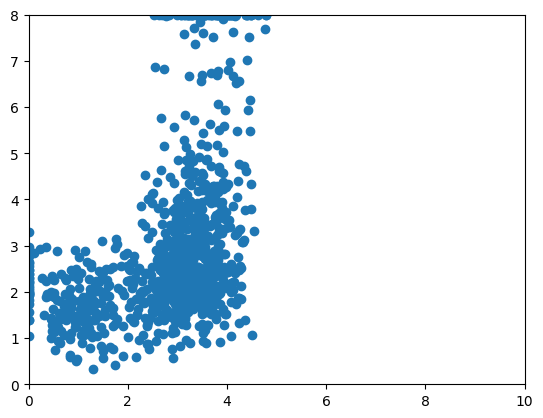

In [17]:
plt.scatter(rl_data[0, :, 0].cpu(), rl_data[0, :, 1].cpu())
plt.xlim(0, 10)
plt.ylim(0, 8)

(0.0, 8.0)

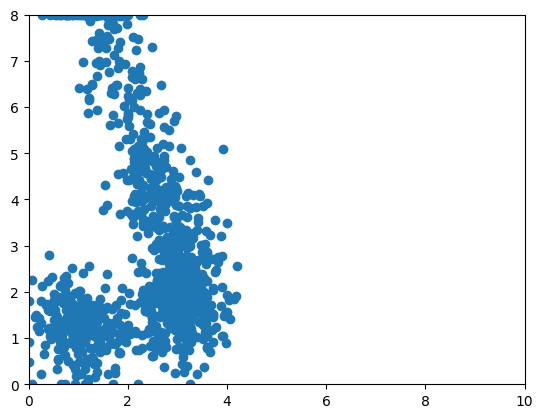

In [28]:
plt.scatter(rl_data[1, :, 0].cpu(), rl_data[1, :, 1].cpu())
plt.xlim(0, 10)
plt.ylim(0, 8)

(0.0, 8.0)

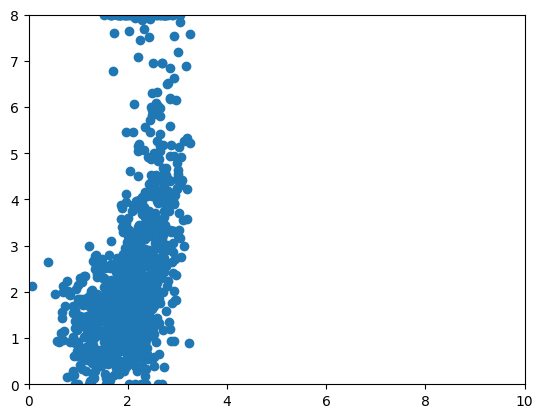

In [29]:
plt.scatter(rl_data[2, :, 0].cpu(), rl_data[2, :, 1].cpu())
plt.xlim(0, 10)
plt.ylim(0, 8)

(0.0, 8.0)

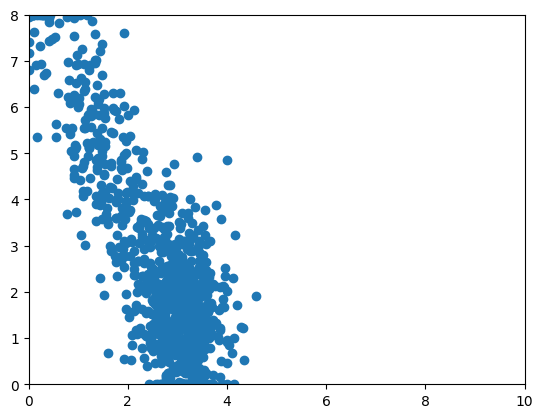

In [30]:
plt.scatter(rl_data[3, :, 0].cpu(), rl_data[3, :, 1].cpu())
plt.xlim(0, 10)
plt.ylim(0, 8)

(0.0, 8.0)

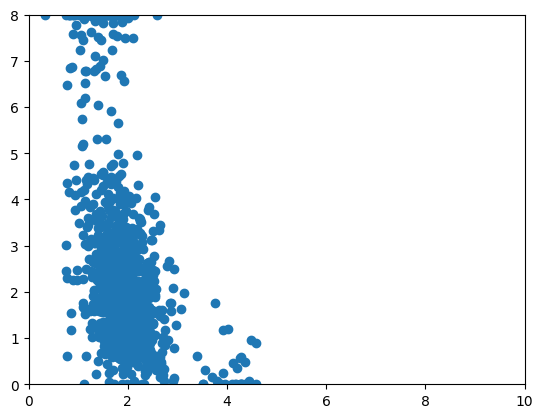

In [31]:
plt.scatter(rl_data[4, :, 0].cpu(), rl_data[4, :, 1].cpu())
plt.xlim(0, 10)
plt.ylim(0, 8)

(0.0, 8.0)

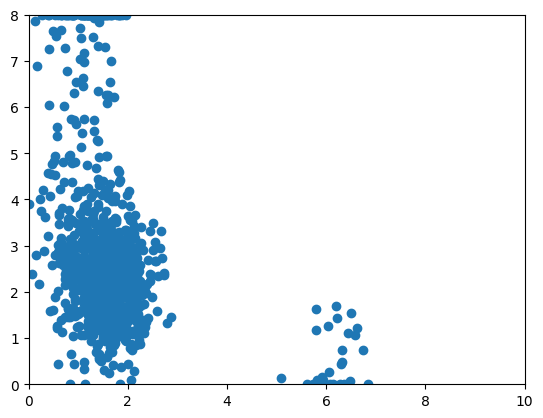

In [32]:
plt.scatter(rl_data[5, :, 0].cpu(), rl_data[5, :, 1].cpu())
plt.xlim(0, 10)
plt.ylim(0, 8)

# Reacher data

In [54]:
def reacher_data_gen():
    """
    Loads the reacher reward weighting dataset.
    """

    data_1 = torch.load("../DTR-Bench/reacher_data_1.pt")
    data_5 = torch.load("../DTR-Bench/reacher_data_5.pt")
    data = torch.stack([data_1, data_5], dim=0)  # Stack along a new dimension
    data = data.to(device)
    return data

In [55]:
reacher_data = reacher_data_gen()

In [56]:
reacher_data.shape

torch.Size([2, 1000, 13])

In [9]:
# Activation class
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class
class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 1):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_dim+cond_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
            )
    

    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t, cond], dim=1)
        output = self.main(h)
        
        return output.reshape(*sz)

In [19]:
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class with FiLM conditioning
class FiLMMLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 1):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim
        
        # Main network layers
        self.input_layer = nn.Linear(input_dim + time_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(3)
        ])
        self.output_layer = nn.Linear(hidden_dim, input_dim)
        
        self.activation = Swish()
        
        # FiLM generator network
        # It will generate gammas and betas for the 4 layers (input + 3 hidden)
        num_film_layers = len(self.hidden_layers) + 1 
        self.film_generator = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            self.activation,
            nn.Linear(hidden_dim, num_film_layers * hidden_dim * 2) # *2 for gamma and beta
        )
        
    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        # Expand time to match batch size
        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        
        # Generate FiLM parameters from condition
        film_params = self.film_generator(cond)
        
        # Split FiLM params into gammas and betas for each layer
        num_film_layers = len(self.hidden_layers) + 1
        gammas = film_params[:, :num_film_layers * self.hidden_dim].reshape(-1, num_film_layers, self.hidden_dim)
        betas = film_params[:, num_film_layers * self.hidden_dim:].reshape(-1, num_film_layers, self.hidden_dim)

        # Main forward pass
        h = torch.cat([x, t], dim=1)
        
        # Input layer
        h = self.input_layer(h)
        h = gammas[:, 0, :] * h + betas[:, 0, :] # Apply FiLM
        h = self.activation(h)
        
        # Hidden layers
        for i, layer in enumerate(self.hidden_layers):
            h = layer(h)
            h = gammas[:, i + 1, :] * h + betas[:, i + 1, :] # Apply FiLM
            h = self.activation(h)
            
        # Output layer
        output = self.output_layer(h)
        
        return output.reshape(*sz)

In [37]:
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class with FiLM conditioning - ONLY on first layer
class FiLMMLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 7):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim
        
        # Main network layers
        self.input_layer = nn.Linear(input_dim + time_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(3)
        ])
        self.output_layer = nn.Linear(hidden_dim, input_dim)
        
        self.activation = Swish()
        
        # FiLM generator network - ONLY for first layer
        self.film_generator = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            self.activation,
            nn.Linear(hidden_dim, hidden_dim * 2)  # Only gamma and beta for first layer
        )
        
    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        # Expand time to match batch size
        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        
        # Generate FiLM parameters from condition - only for first layer
        film_params = self.film_generator(cond)
        gamma = film_params[:, :self.hidden_dim]  # First half
        beta = film_params[:, self.hidden_dim:]   # Second half

        # Main forward pass
        h = torch.cat([x, t], dim=1)
        
        # Input layer with FiLM conditioning
        h = self.input_layer(h)
        h = gamma * h + beta  # Apply FiLM only here
        h = self.activation(h)
        
        # Hidden layers WITHOUT FiLM conditioning
        for layer in self.hidden_layers:
            h = layer(h)
            h = self.activation(h)
            
        # Output layer
        output = self.output_layer(h)
        
        return output.reshape(*sz)

In [38]:
class WrappedModel(ModelWrapper):
        def forward(self, x: torch.Tensor, t: torch.Tensor, cond: torch.Tensor, **extras):
            return self.model(x, t, cond)

In [39]:
for model_i in range(5):
    print(f"Iteration {model_i+1} of 5")
    print("-" * 60)

    lr = 1e-3
    batch_size = 1000
    iterations = 100001
    print_every = 2000 
    hidden_dim = 128
    patience = 100
    min_delta = 0  
    validation_split = 0.1 

    num_samples = reacher_data.shape[1]
    val_size = int(num_samples * validation_split)
    val_indices = torch.randperm(num_samples)[:val_size]
    train_indices = torch.randperm(num_samples)[val_size:]

    vf_0 = FiLMMLP(input_dim=2, time_dim=1, cond_dim=11, hidden_dim=hidden_dim).to(device) 
    path = AffineProbPath(scheduler=CondOTScheduler())
    optim = torch.optim.Adam(vf_0.parameters(), lr=lr) 

    best_val_loss_0 = float('inf')
    patience_counter_0 = 0
    best_model_state_0 = None

    start_time = time.time()
    for i in range(iterations):
        vf_0.train()
        optim.zero_grad() 

        x_1 = reacher_data[1, train_indices, :2] 
        x_0 = reacher_data[0, train_indices, :2]
        conds = reacher_data[0, train_indices, 2:]
        t = torch.rand(x_1.shape[0]).to(device) 
        path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)
        train_loss = torch.pow(vf_0(path_sample.x_t, path_sample.t, conds) - path_sample.dx_t, 2).mean() 
        train_loss.backward() 
        optim.step()
        
        if i % 100 == 0:
            vf_0.eval()
            with torch.no_grad():
                x_1_val = reacher_data[1, val_indices, :2] 
                x_0_val = reacher_data[0, val_indices, :2]
                conds_val = reacher_data[0, val_indices, 2:]
                t_val = torch.rand(x_1_val.shape[0]).to(device) 
                path_sample_val = path.sample(t=t_val, x_0=x_0_val, x_1=x_1_val)
                val_loss = torch.pow(vf_0(path_sample_val.x_t, path_sample_val.t, conds_val) - path_sample_val.dx_t, 2).mean()
                
                if val_loss < best_val_loss_0 - min_delta:
                    best_val_loss_0 = val_loss
                    patience_counter_0 = 0
                    best_model_state_0 = vf_0.state_dict().copy()
                else:
                    patience_counter_0 += 1

        if (i+1) % print_every == 0:
            elapsed = time.time() - start_time
            print('| iter {:6d} | {:5.2f} ms/step | train loss {:8.6f} | val loss {:8.6f} | patience {:3d}/{:3d}' 
                .format(i+1, elapsed*1000/print_every, train_loss.item(), val_loss.item(), patience_counter_0, patience)) 
            start_time = time.time()
        
        if patience_counter_0 >= patience:
            print(f"Early stopping triggered at iteration {i+1}")
            print(f"Best validation loss: {best_val_loss_0:.6f}")
            if best_model_state_0 is not None:
                vf_0.load_state_dict(best_model_state_0)
                print("Restored best model weights")
            break

    print(f"Training completed for vf_0 after {i+1} iterations")

    wrapped_vf_0 = WrappedModel(vf_0)
    torch.save(wrapped_vf_0.state_dict(), f'cfm_reacher_FiLM_leaky_model_{model_i}.pt')


Iteration 1 of 5
------------------------------------------------------------
| iter   2000 |  1.72 ms/step | train loss 0.000023 | val loss 0.000028 | patience   1/100
| iter   4000 |  1.72 ms/step | train loss 0.000011 | val loss 0.000015 | patience   1/100
| iter   6000 |  1.71 ms/step | train loss 0.000008 | val loss 0.000009 | patience   2/100
| iter   8000 |  1.71 ms/step | train loss 0.000010 | val loss 0.000006 | patience   2/100
| iter  10000 |  1.71 ms/step | train loss 0.000005 | val loss 0.000004 | patience   9/100
| iter  12000 |  1.70 ms/step | train loss 0.000001 | val loss 0.000001 | patience   0/100
| iter  14000 |  1.71 ms/step | train loss 0.000001 | val loss 0.000001 | patience   9/100
| iter  16000 |  1.71 ms/step | train loss 0.000001 | val loss 0.000002 | patience  16/100
| iter  18000 |  1.71 ms/step | train loss 0.000001 | val loss 0.000000 | patience   4/100
| iter  20000 |  1.71 ms/step | train loss 0.000000 | val loss 0.000001 | patience  24/100
| iter  2200

In [40]:
step_size = 0.05
T = torch.linspace(0,1,5)
T = T.to(device=device)
x_init = reacher_data[0,:,:2]
cond = reacher_data[0,:,2:]
solver_0 = ODESolver(velocity_model=wrapped_vf_0) 
sol_0 = solver_0.sample(time_grid=T, x_init=x_init, cond=cond, method='midpoint', step_size=step_size, return_intermediates=True) 

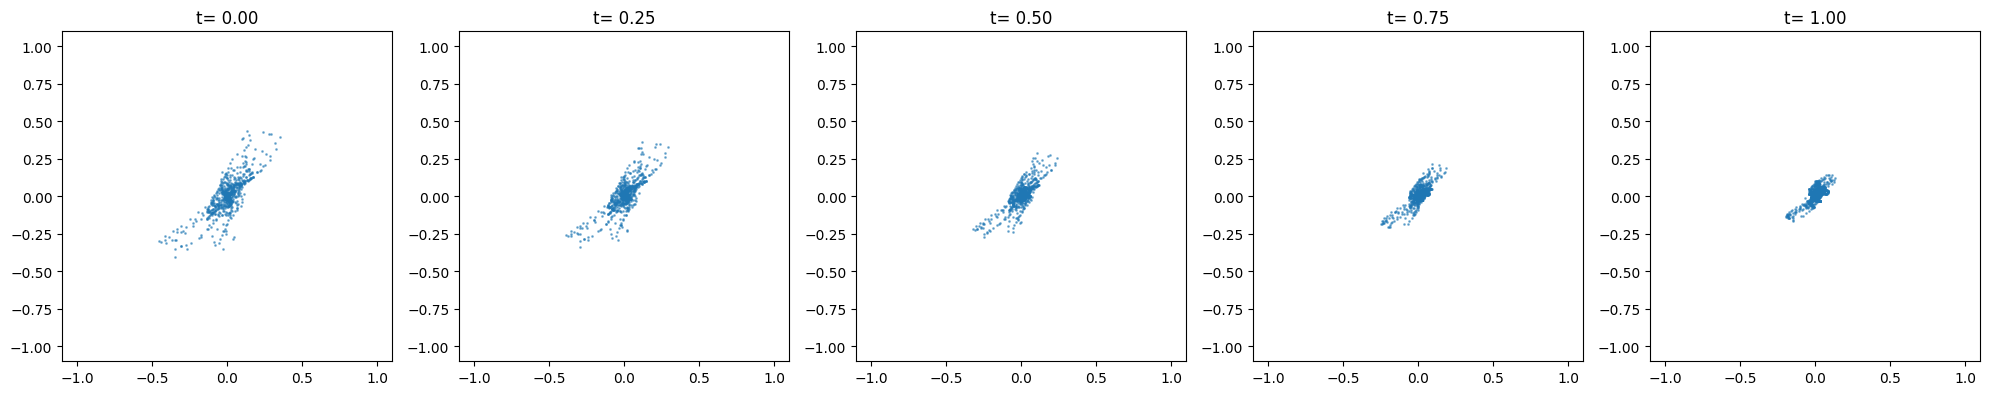

In [41]:
sol_0 = sol_0.cpu().numpy()
T = T.cpu()
cond = cond.cpu().numpy()
fig, axs = plt.subplots(1, 5,figsize=(20,20))

for i in range(5):
    #clip the values to [-1,1] and [-1,1]
    sol_0[i,:,0] = np.clip(sol_0[i,:,0], -1, 1)
    sol_0[i,:,1] = np.clip(sol_0[i,:,1], -1, 1)
    axs[i].scatter(sol_0[i,:,0], sol_0[i,:,1], s=1, alpha=0.5)
    axs[i].set_aspect('equal')
    axs[i].set_xlim(-1.1, 1.1)
    axs[i].set_ylim(-1.1, 1.1)
    axs[i].set_title('t= %.2f' % (T[i]))
    
plt.tight_layout()
plt.show()

# ETT forecasting data

In [11]:
def ett_data_gen():
    """
    Loads the ETT forecast dataset.
    """
    data = torch.load("../robustness/ett_forecasts_iclr.pt")
    data = data[[0,4]]
    data = data.to(device)
    return data
ett = ett_data_gen()
forecast_portion = ett[:,:,24:]
input_portion = ett[:,:,:24]
ett_reversed = torch.concat([forecast_portion, input_portion], dim=2)

In [12]:
def ett_test_data_gen():
    """
    Loads the ETT forecast dataset.
    """
    data = torch.load("../robustness/ett_forecasts_iclr.pt")
    data = data.to(device)
    return data

In [13]:
# Activation class
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class
class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 1):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_dim+cond_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
            )
    

    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t, cond], dim=1)
        output = self.main(h)
        
        return output.reshape(*sz)

In [14]:
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class with FiLM conditioning - ONLY on first layer
class FiLMMLP(nn.Module):
    def __init__(self, input_dim: int = 12, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 24):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim
        
        # Main network layers
        self.input_layer = nn.Linear(input_dim + time_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(3)
        ])
        self.output_layer = nn.Linear(hidden_dim, input_dim)
        
        self.activation = Swish()
        
        # FiLM generator network - ONLY for first layer
        self.film_generator = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            self.activation,
            nn.Linear(hidden_dim, hidden_dim * 2)  # Only gamma and beta for first layer
        )
        
    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        # Expand time to match batch size
        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        
        # Generate FiLM parameters from condition - only for first layer
        film_params = self.film_generator(cond)
        gamma = film_params[:, :self.hidden_dim]  # First half
        beta = film_params[:, self.hidden_dim:]   # Second half

        # Main forward pass
        h = torch.cat([x, t], dim=1)
        
        # Input layer with FiLM conditioning
        h = self.input_layer(h)
        h = gamma * h + beta  # Apply FiLM only here
        h = self.activation(h)
        
        # Hidden layers WITHOUT FiLM conditioning
        for layer in self.hidden_layers:
            h = layer(h)
            h = self.activation(h)
            
        # Output layer
        output = self.output_layer(h)
        
        return output.reshape(*sz)

In [15]:
class WrappedModel(ModelWrapper):
        def forward(self, x: torch.Tensor, t: torch.Tensor, cond: torch.Tensor, **extras):
            return self.model(x, t, cond)

In [63]:
for model_i in range(5):
    print(f"Iteration {model_i+1} of 5")
    print("-" * 60)

    lr = 1e-4
    batch_size = 64
    iterations = 10000
    print_every = 100 
    hidden_dim = 128
    patience = 250
    min_delta = 0  
    validation_split = 0.1 

    #num_samples = ett_reversed.shape[1]
    num_samples = 1450 #leaving the last 50 samples for testing
    val_size = int(num_samples * validation_split)
    #val_indices = torch.randperm(num_samples)[:val_size]
    #train_indices = torch.randperm(num_samples)[val_size:]
    train_indices = torch.arange(num_samples - val_size)
    val_indices = torch.arange(num_samples - val_size, num_samples)

    vf_0 = FiLMMLP(input_dim=12, time_dim=1, cond_dim=24, hidden_dim=hidden_dim).to(device) 
    path = AffineProbPath(scheduler=CondOTScheduler())
    optim = torch.optim.Adam(vf_0.parameters(), lr=lr) 

    best_val_loss_0 = float('inf')
    patience_counter_0 = 0
    best_model_state_0 = None

    start_time = time.time()
    losses = []
    val_losses = []
    for i in range(iterations):
        vf_0.train()
        optim.zero_grad() 

        x_1 = ett_reversed[1, train_indices, :12] 
        x_0 = ett_reversed[0, train_indices, :12]
        conds = ett_reversed[0, train_indices, 12:]
        t = torch.rand(x_1.shape[0]).to(device) 
        path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)
        train_loss = torch.pow(vf_0(path_sample.x_t, path_sample.t, conds) - path_sample.dx_t, 2).mean() 
        train_loss.backward() 
        optim.step()
        losses.append(train_loss.item())
        
        vf_0.eval()
        with torch.no_grad():
            x_1_val = ett_reversed[1, val_indices, :12] 
            x_0_val = ett_reversed[0, val_indices, :12]
            conds_val = ett_reversed[0, val_indices, 12:]
            t_val = torch.rand(x_1_val.shape[0]).to(device) 
            path_sample_val = path.sample(t=t_val, x_0=x_0_val, x_1=x_1_val)
            val_loss = torch.pow(vf_0(path_sample_val.x_t, path_sample_val.t, conds_val) - path_sample_val.dx_t, 2).mean()
            val_losses.append(val_loss.item())
            
            if val_loss < best_val_loss_0 - min_delta:
                best_val_loss_0 = val_loss
                patience_counter_0 = 0
                best_model_state_0 = vf_0.state_dict().copy()
            else:
                patience_counter_0 += 1

        if (i+1) % print_every == 0:
            elapsed = time.time() - start_time
            print('| iter {:6d} | {:5.2f} ms/step | train loss {:8.6f} | val loss {:8.6f} | patience {:3d}/{:3d}' 
                .format(i+1, elapsed*1000/print_every, train_loss.item(), val_loss.item(), patience_counter_0, patience)) 
            start_time = time.time()
        
        if patience_counter_0 >= patience:
            print(f"Early stopping triggered at iteration {i+1}")
            print(f"Best validation loss: {best_val_loss_0:.6f}")
            if best_model_state_0 is not None:
                vf_0.load_state_dict(best_model_state_0)
                print("Restored best model weights")
            break

    print(f"Training completed for vf_0 after {i+1} iterations")

    wrapped_vf_0 = WrappedModel(vf_0)
    torch.save(wrapped_vf_0.state_dict(), f'cfm_ett_FiLM_model_{model_i}.pt')


Iteration 1 of 5
------------------------------------------------------------


| iter    100 |  3.50 ms/step | train loss 1.367231 | val loss 0.714681 | patience   0/250
| iter    200 |  3.46 ms/step | train loss 0.343126 | val loss 0.260371 | patience   5/250
| iter    300 |  3.35 ms/step | train loss 0.201811 | val loss 0.204144 | patience  81/250
| iter    400 |  3.52 ms/step | train loss 0.141511 | val loss 0.086489 | patience   0/250
| iter    500 |  3.43 ms/step | train loss 0.139231 | val loss 0.185224 | patience  57/250
| iter    600 |  3.45 ms/step | train loss 0.075921 | val loss 0.088038 | patience  33/250
| iter    700 |  3.45 ms/step | train loss 0.080968 | val loss 0.054387 | patience   9/250
| iter    800 |  3.46 ms/step | train loss 0.059972 | val loss 0.053632 | patience  65/250
| iter    900 |  3.44 ms/step | train loss 0.130085 | val loss 0.241472 | patience  19/250
| iter   1000 |  3.41 ms/step | train loss 0.044293 | val loss 0.044330 | patience  35/250
| iter   1100 |  3.48 ms/step | train loss 0.041494 | val loss 0.045601 | patience  91/250

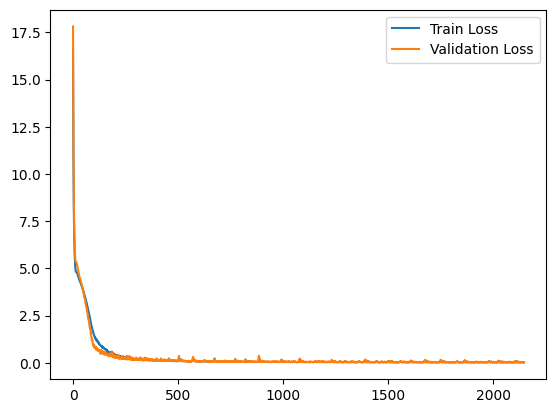

In [64]:
plt.plot(losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()

In [65]:
ett_testing = ett_test_data_gen()

In [66]:
def cfm_ett_evaluation(model, lam):
    step_size = 0.05
    T = torch.linspace(0,1,5)
    T = T.to(device=device)
    x_init = ett_testing[0,50:,24:]
    cond = ett_testing[0,50:,:24]
    solver_0 = ODESolver(velocity_model=model) 
    sol_0 = solver_0.sample(time_grid=T, x_init=x_init, cond=cond, method='midpoint', step_size=step_size, return_intermediates=True) 

    mses = []
    for i in range(450):
        mse = ett_testing[lam][50+i][24:].cpu().numpy() - sol_0[lam][i].cpu().numpy()
        mses.append(np.mean(mse**2))
    
    return np.mean(mses)

In [67]:
mses = []
for j in range(5):
    model_mses = []
    for lam in [1,2,3]:
        model_path = f'cfm_ett_FiLM_model_{j}.pt'
        model = FiLMMLP(input_dim=12, time_dim=1, cond_dim=24, hidden_dim=128).to(device)
        wrapped_model = WrappedModel(model)
        wrapped_model.load_state_dict(torch.load(model_path))
        model.eval()
        mse = cfm_ett_evaluation(model, lam)
        model_mses.append(mse)
        print(f"Model {j}, lamba {lam} MSE: {mse:.6f}")
    mses.append(model_mses)

Model 0, lamba 1 MSE: 0.346896
Model 0, lamba 2 MSE: 0.331766
Model 0, lamba 3 MSE: 0.150581
Model 1, lamba 1 MSE: 0.338744
Model 1, lamba 2 MSE: 0.324782
Model 1, lamba 3 MSE: 0.147913
Model 2, lamba 1 MSE: 0.340467
Model 2, lamba 2 MSE: 0.331044
Model 2, lamba 3 MSE: 0.142562
Model 3, lamba 1 MSE: 0.339136
Model 3, lamba 2 MSE: 0.329465
Model 3, lamba 3 MSE: 0.144027
Model 4, lamba 1 MSE: 0.341314
Model 4, lamba 2 MSE: 0.328515
Model 4, lamba 3 MSE: 0.143210


In [68]:
print_results([np.mean(i) for i in mses],'ett flow surrogate results')

ett flow surrogate results: 0.272 ± 0.002


In [69]:
step_size = 0.05
T = torch.linspace(0,1,5)
T = T.to(device=device)
x_init = ett[0,50:,24:]
cond = ett[0,50:,:24]
solver_0 = ODESolver(velocity_model=wrapped_vf_0) 
sol_0 = solver_0.sample(time_grid=T, x_init=x_init, cond=cond, method='midpoint', step_size=step_size, return_intermediates=True) 

In [70]:
sol_0

tensor([[[ 6.9254,  6.8823,  6.8363,  ...,  6.5394,  6.5009,  6.5517],
         [17.5213, 17.2787, 16.9244,  ..., 14.7475, 14.3289, 14.4630],
         [10.6826, 10.6710, 10.6535,  ..., 10.6121, 10.5407, 10.6106],
         ...,
         [42.3698, 42.2676, 42.0413,  ..., 41.2523, 41.0461, 41.1851],
         [41.0348, 41.3009, 41.5501,  ..., 43.3082, 43.6199, 43.6584],
         [48.2004, 48.1667, 48.1995,  ..., 48.2496, 48.0707, 48.1330]],

        [[ 6.9772,  6.9434,  6.9034,  ...,  6.6759,  6.6381,  6.6918],
         [17.7530, 17.5638, 17.3102,  ..., 15.4216, 15.0720, 15.2156],
         [10.6616, 10.6518, 10.6246,  ..., 10.5888, 10.5124, 10.5792],
         ...,
         [42.5263, 42.4574, 42.2671,  ..., 41.7245, 41.4918, 41.6311],
         [40.7501, 40.9798, 41.1394,  ..., 42.5256, 42.7737, 42.8115],
         [48.1903, 48.1478, 48.1568,  ..., 48.1372, 47.9878, 48.1161]],

        [[ 7.0289,  7.0042,  6.9693,  ...,  6.8088,  6.7700,  6.8280],
         [17.9885, 17.8476, 17.6969,  ..., 16

In [71]:
ett_testing[0][0]

tensor([13.4910, 13.4910, 13.4910, 13.4910, 13.4910, 13.7110, 13.9310, 14.8100,
        15.2490, 15.6885, 16.1280, 16.5670, 16.5670, 16.7870, 16.7870, 16.7870,
        17.0065, 17.2265, 17.2265, 17.6660, 17.6660, 17.8860, 18.3250, 18.9845,
        19.0732, 19.1208, 19.1327, 19.1092, 19.2016, 18.8690, 19.0455, 19.1084,
        19.0983, 18.8067, 18.5803, 18.9281], device='cuda:0')

In [72]:
sol_0[0][0]

tensor([6.9254, 6.8823, 6.8363, 6.7691, 6.7536, 6.7408, 6.6740, 6.6309, 6.6436,
        6.5394, 6.5009, 6.5517], device='cuda:0')

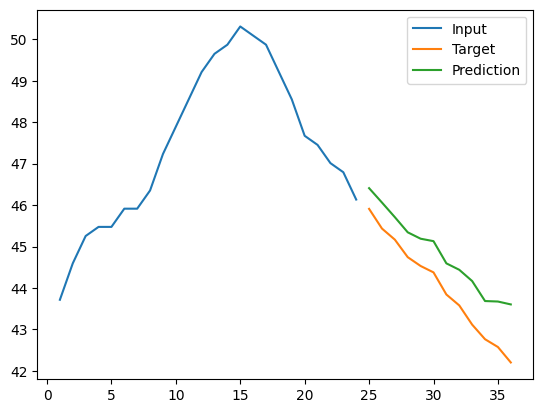

In [76]:
mses = []
noise = 1
for i in [401]:
    mse = ett_testing[noise][50+i][24:].cpu().numpy() - sol_0[noise][i].cpu().numpy()
    plt.plot(np.linspace(1, 24, 24), ett_testing[noise][50+i][:24].cpu().numpy(), label='Input')
    plt.plot(np.linspace(25, 36, 12),ett_testing[noise][50+i][24:].cpu().numpy(), label='Target')
    plt.plot(np.linspace(25, 36, 12),sol_0[noise][i].cpu().numpy(), label='Prediction')
    plt.legend()
    mses.append(np.mean(mse**2))

In [77]:
np.mean(mses)

0.7264947